In [ ]:
# ============================================================
#  Carga y Exploración Inicial de Datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv("cyberbullying_tweets.csv")

# Información general
print("=== FORMA DEL DATASET ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n=== PRIMERAS 5 FILAS ===")
print(df.head())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== DISTRIBUCIÓN DE CLASES ===")
print(df['cyberbullying_type'].value_counts())

=== FORMA DEL DATASET ===
Filas: 47692, Columnas: 2

=== PRIMERAS 5 FILAS ===
                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying

=== TIPOS DE DATOS ===
tweet_text            str
cyberbullying_type    str
dtype: object

=== VALORES NULOS ===
tweet_text            0
cyberbullying_type    0
dtype: int64

=== DISTRIBUCIÓN DE CLASES ===
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


C:\Users\hugob\AppData\Local\Temp\ipykernel_17068\3675121458.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cyberbullying_type', order=order, palette='viridis')


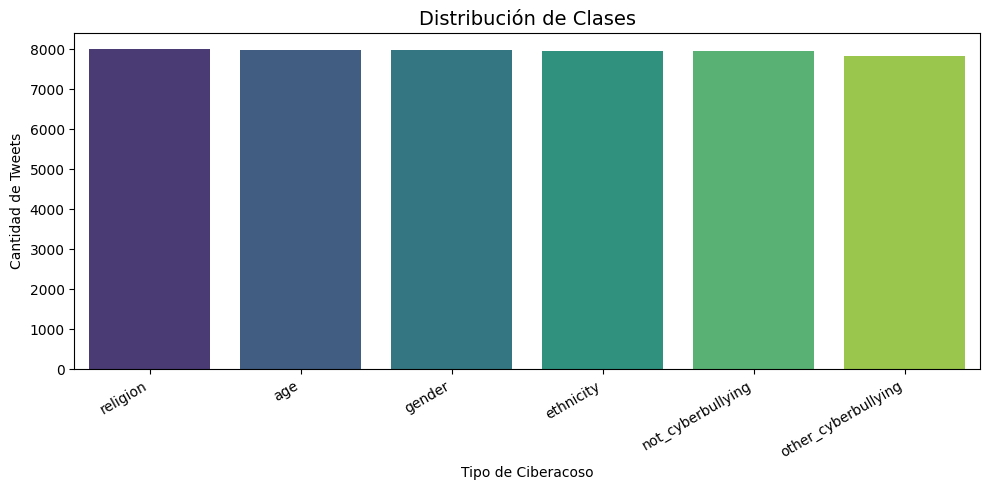

C:\Users\hugob\AppData\Local\Temp\ipykernel_17068\3675121458.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cyberbullying_type', y='tweet_length', order=order, palette='viridis')


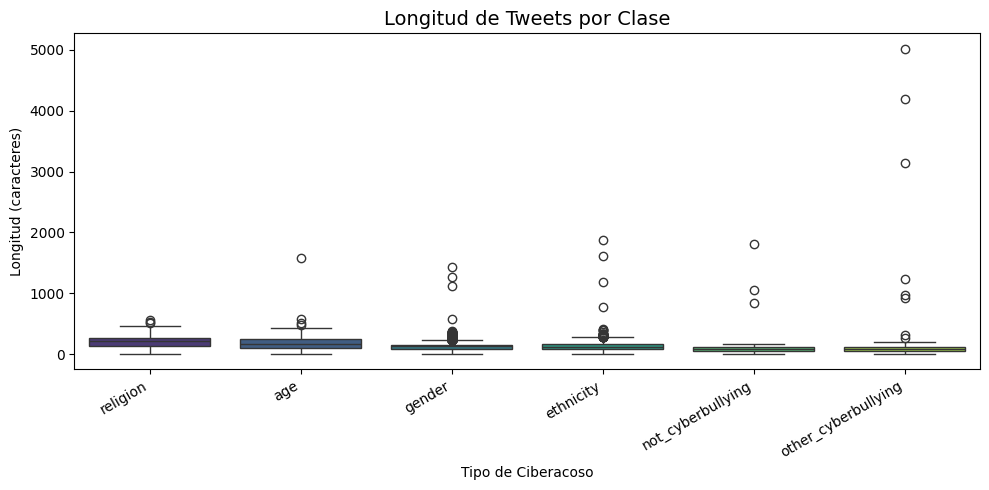

=== ESTADÍSTICAS DE LONGITUD DE TWEETS ===
                      count   mean   std   min    25%    50%    75%     max
cyberbullying_type                                                         
age                  7992.0  173.5  80.1  11.0  105.0  171.0  252.0  1585.0
ethnicity            7961.0  139.3  76.8   5.0   88.0  126.0  167.0  1869.0
gender               7973.0  136.4  71.4   2.0   89.0  129.0  147.0  1431.0
not_cyberbullying    7945.0   83.1  45.5   2.0   49.0   81.0  119.0  1809.0
other_cyberbullying  7823.0   85.7  91.7   1.0   51.0   83.0  121.0  5018.0
religion             7998.0  198.0  71.9   7.0  134.0  212.0  269.0   568.0


In [ ]:
# ============================================================
#  Análisis Exploratorio de Datos
# ============================================================

# --- Gráfica 1: Distribución de clases ---
plt.figure(figsize=(10, 5))
order = df['cyberbullying_type'].value_counts().index
sns.countplot(data=df, x='cyberbullying_type', order=order, palette='viridis')
plt.title('Distribución de Clases', fontsize=14)
plt.xlabel('Tipo de Ciberacoso')
plt.ylabel('Cantidad de Tweets')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150)
plt.show()

# --- Gráfica 2: Longitud de tweets por clase ---
df['tweet_length'] = df['tweet_text'].apply(len)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='cyberbullying_type', y='tweet_length', order=order, palette='viridis')
plt.title('Longitud de Tweets por Clase', fontsize=14)
plt.xlabel('Tipo de Ciberacoso')
plt.ylabel('Longitud (caracteres)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('longitud_tweets.png', dpi=150)
plt.show()

# --- Estadísticas de longitud ---
print("=== ESTADÍSTICAS DE LONGITUD DE TWEETS ===")
print(df.groupby('cyberbullying_type')['tweet_length'].describe().round(1))

In [ ]:
# ============================================================
#  Limpieza y Preprocesamiento de Texto (NLP Pipeline)
# ============================================================
import re
import nltk

# Descargar recursos necesarios de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Inicializar el lematizador y stopwords en inglés
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def limpiar_tweet(texto):
    # 1. Convertir a minúsculas
    texto = texto.lower()
    # 2. Eliminar URLs
    texto = re.sub(r'http\S+|www\S+', '', texto)
    # 3. Eliminar menciones (@usuario)
    texto = re.sub(r'@\w+', '', texto)
    # 4. Eliminar hashtags (#tema)
    texto = re.sub(r'#\w+', '', texto)
    # 5. Eliminar caracteres especiales, números y emojis
    texto = re.sub(r'[^a-z\s]', '', texto)
    # 6. Eliminar espacios extra
    texto = re.sub(r'\s+', ' ', texto).strip()
    # 7. Tokenizar (separar en palabras)
    palabras = texto.split()
    # 8. Eliminar stopwords y lematizar
    palabras = [lemmatizer.lemmatize(p) for p in palabras if p not in stop_words]
    return ' '.join(palabras)

# Aplicar limpieza a todos los tweets
print("Limpiando tweets...")
df['tweet_clean'] = df['tweet_text'].apply(limpiar_tweet)

# Verificar resultados
print("\n=== EJEMPLO DE LIMPIEZA ===")
for i in range(3):
    print(f"\nORIGINAL:  {df['tweet_text'].iloc[i]}")
    print(f"LIMPIO:    {df['tweet_clean'].iloc[i]}")

# Verificar tweets vacíos después de limpiar
vacios = (df['tweet_clean'].str.strip() == '').sum()
print(f"\n=== TWEETS VACÍOS DESPUÉS DE LIMPIAR: {vacios} ===")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hugob\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hugob\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hugob\AppData\Roaming\nltk_data...


Limpiando tweets...

=== EJEMPLO DE LIMPIEZA ===

ORIGINAL:  In other words #katandandre, your food was crapilicious! #mkr
LIMPIO:    word food crapilicious

ORIGINAL:  Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc
LIMPIO:    white

ORIGINAL:  @XochitlSuckkks a classy whore? Or more red velvet cupcakes?
LIMPIO:    classy whore red velvet cupcake

=== TWEETS VACÍOS DESPUÉS DE LIMPIAR: 477 ===


In [ ]:
# ============================================================
#  Eliminación de vacíos y Vectorización TF-IDF
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Eliminar tweets que quedaron vacíos después de limpiar
df = df[df['tweet_clean'].str.strip() != '']
print(f"Tweets restantes después de limpieza: {len(df)}")

# --- Separar X (texto) e y (etiqueta) ---
X = df['tweet_clean']
y = df['cyberbullying_type']

# --- División Train/Test (80% entrenamiento, 20% prueba) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTamaño Train: {len(X_train)} tweets")
print(f"Tamaño Test:  {len(X_test)} tweets")

# --- Vectorización TF-IDF ---
# max_features=10000: usar las 10,000 palabras más importantes
# ngram_range=(1,2): considerar palabras solas y pares de palabras
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Ajustar SOLO con train, transformar ambos
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nDimensión matriz Train: {X_train_tfidf.shape}")
print(f"Dimensión matriz Test:  {X_test_tfidf.shape}")
print("\n✅ Vectorización TF-IDF completada")

Tweets restantes después de limpieza: 47215

Tamaño Train: 37772 tweets
Tamaño Test:  9443 tweets

Dimensión matriz Train: (37772, 10000)
Dimensión matriz Test:  (9443, 10000)

✅ Vectorización TF-IDF completada
